# Process variables analysis

- Plotar as variáveis de processo em uma série temporal marcando o tipo de falha relevante para a variável e indicando os possíveis limites de operação normal
- Para os casos onde os limites são definidos por mais de uma variável testar duas estratégias: criar uma nova feature multiplicando as variáveis para combiná-las e indicar os limites no gráfico dessa nova variável e fazer um plot de cada variável em um eixo delimitando os limites usando um retângulo
- Verificar como estão distribuídos os tipos de produto no histórico (aleatório ou campanhas) plotando os pontos em uma linha do tempo colorida conforme o tipo de produto e depois usando o método das matrizes de transição para provar a aleatoriedade da distribuição de produtos.

## Time-series plot of process variables

In [3]:
import pandas as pd
from sqlalchemy import create_engine
from local_settings import postgres_url as url
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load 'milling_pdm_celsius' dataset to a pandas dataframe and show
url = f"postgresql+psycopg2://{url['pguser']}:{url['pgpassword']}@{url['pghost']}/{url['pgdb']}"
engine = create_engine(url)
df = pd.read_sql(f"SELECT * FROM milling_pdm_celsius",con=engine, index_col="register_id")
df

,product_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
register_id,,,,,,,,,,,,,
1,M14860,M,24.950006,35.450006,1551.0,42.8,0,False,False,False,False,False,False
2,L47181,L,25.050012,35.550012,1408.0,46.3,3,False,False,False,False,False,False
3,L47182,L,24.950006,35.350000,1498.0,49.4,5,False,False,False,False,False,False
4,L47183,L,25.050012,35.450006,1433.0,39.5,7,False,False,False,False,False,False
5,L47184,L,25.050012,35.550012,1408.0,40.0,9,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,M24855,M,25.649988,35.249994,1604.0,29.5,14,False,False,False,False,False,False
9997,H39410,H,25.749994,35.249994,1632.0,31.8,17,False,False,False,False,False,False
9998,M24857,M,25.850000,35.450006,1645.0,33.4,22,False,False,False,False,False,False


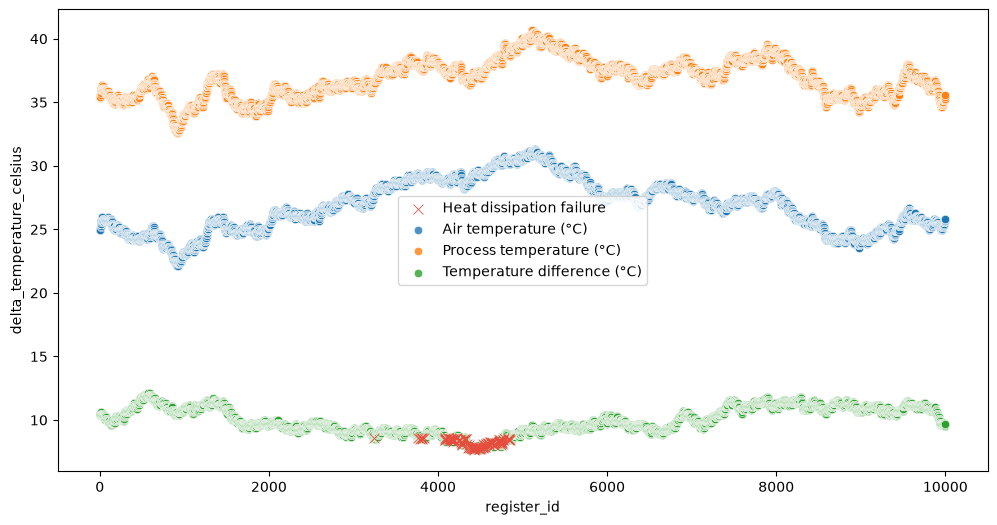

In [23]:
# Time-series plot of air_temperature_celsius
df["delta_temperature_celsius"] = df["process_temperature_celsius"] - df["air_temperature_celsius"]
df_filtered = df

plt.figure(figsize=(12, 6))



sns.scatterplot(x="register_id",
                y="delta_temperature_celsius",
                data=df[df["heat_dissipation_failure"] == True],
                label="Heat dissipation failure",
                color="#e74c3c",
                marker="x",
                s=50,
                zorder=5)

sns.scatterplot(x="register_id",
             y="air_temperature_celsius",
             data=df_filtered,
             label="Air temperature (°C)",
             alpha=0.8)

sns.scatterplot(x="register_id",
             y="process_temperature_celsius",
             data=df_filtered,
             label="Process temperature (°C)",
             alpha=0.8)

sns.scatterplot(x="register_id",
             y="delta_temperature_celsius",
             data=df_filtered,
             label="Temperature difference (°C)",
             alpha=0.8)

plt.show()

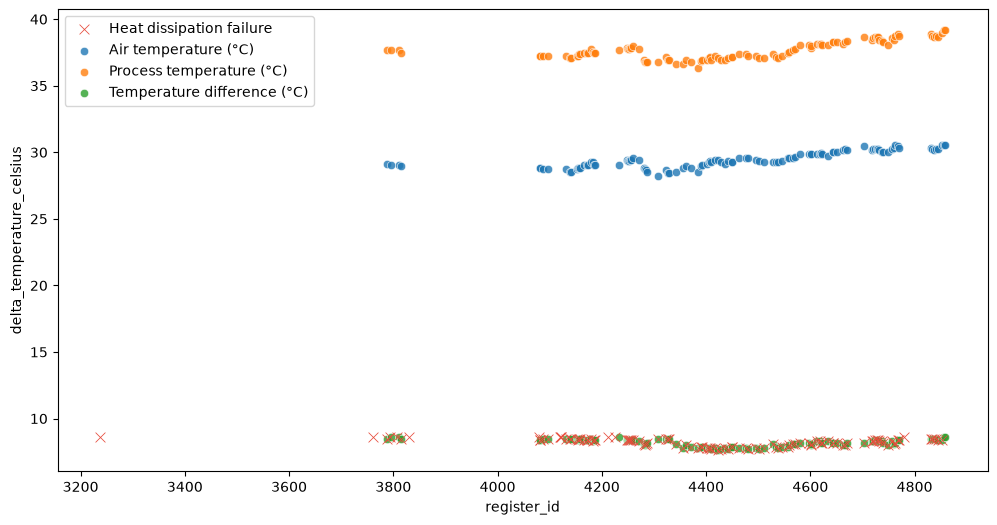

In [47]:
# Time-series plot of air_temperature_celsius
df["delta_temperature_celsius"] = df["process_temperature_celsius"] - df["air_temperature_celsius"]
df_filtered = df[(df["delta_temperature_celsius"] <= 8.6) & (df["rotational_speed_rpm"] <= 1380)]

plt.figure(figsize=(12, 6))



sns.scatterplot(x="register_id",
                y="delta_temperature_celsius",
                data=df[df["heat_dissipation_failure"] == True],
                label="Heat dissipation failure",
                color="#e74c3c",
                marker="x",
                s=50,
                zorder=5)

sns.scatterplot(x="register_id",
             y="air_temperature_celsius",
             data=df_filtered,
             label="Air temperature (°C)",
             alpha=0.8)

sns.scatterplot(x="register_id",
             y="process_temperature_celsius",
             data=df_filtered,
             label="Process temperature (°C)",
             alpha=0.8)

sns.scatterplot(x="register_id",
             y="delta_temperature_celsius",
             data=df_filtered,
             label="Temperature difference (°C)",
             alpha=0.8)

plt.show()

In [48]:
df_filtered.count()

product_id                     108
product_type                   108
air_temperature_celsius        108
process_temperature_celsius    108
rotational_speed_rpm           108
torque_nm                      108
tool_wear_min                  108
machine_failure                108
tool_wear_failure              108
heat_dissipation_failure       108
power_failure                  108
overstrain_failure             108
random_failure                 108
delta_temperature_celsius      108
dtype: int64

In [49]:
df[df["heat_dissipation_failure"]==True].count()

product_id                     115
product_type                   115
air_temperature_celsius        115
process_temperature_celsius    115
rotational_speed_rpm           115
torque_nm                      115
tool_wear_min                  115
machine_failure                115
tool_wear_failure              115
heat_dissipation_failure       115
power_failure                  115
overstrain_failure             115
random_failure                 115
delta_temperature_celsius      115
dtype: int64

In [45]:
# Existem agregações relevantes que causam a aparente multimodalidade do sinal das temperaturas?
# (mostrar que a aparente multimodalidade está relacionada a oscilação da temperatura ao longo do histórico de operação sem uma relação direta
# com o tipo de produto, que é a agregação que poderia causar isso, sendo portanto resultado de diferentes campanhas térmicas da máquina não 
# explicadas pelos dados fornecidos ou possível perda de calibração dos sensores ao longo da operação)

## Timeline of machined products by quality

In [56]:
# Criamos uma coluna que olha qual é o "próximo" produto usinado
df['next_type'] = df['product_type'].shift(-1)

# Calculamos a Matriz de Transição (Probabilidade de ir do Produto X para o Y)
# normalize='index' transforma a contagem em porcentagem por linha
# matriz_transicao = pd.crosstab(df['product_type'], df['next_type'], normalize='index') * 100
matriz_transicao = pd.crosstab(df['product_type'], df['next_type'])

print(matriz_transicao.round(1))

next_type       H     L     M
product_type                 
H             109   591   303
L             596  3619  1785
M             298  1790   908


In [66]:
df_failure_mode = pd.read_sql(f"SELECT * FROM failure_data_unpivoted",con=engine, index_col="register_id")
df_failure_mode.reset_index(inplace=True)
df_failure_mode

,register_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,machine_failure,status
0,1,M,24.950006,35.450006,1551.0,42.8,False,NORMAL
1,2,L,25.050012,35.550012,1408.0,46.3,False,NORMAL
2,3,L,24.950006,35.350000,1498.0,49.4,False,NORMAL
3,4,L,25.050012,35.450006,1433.0,39.5,False,NORMAL
4,5,L,25.050012,35.550012,1408.0,40.0,False,NORMAL
...,...,...,...,...,...,...,...,...
10011,9996,M,25.649988,35.249994,1604.0,29.5,False,NORMAL
10012,9997,H,25.749994,35.249994,1632.0,31.8,False,NORMAL
10013,9998,M,25.850000,35.450006,1645.0,33.4,False,NORMAL
10014,9999,H,25.850000,35.550012,1408.0,48.5,False,NORMAL


In [67]:
import pandas as pd
import numpy as np

# A mágica que você descreveu:
tabela_diagnostico_termico = pd.crosstab(
    index=df_failure_mode['product_type'],                # Linhas: Tipo de Produto (L, M, H)
    columns=df_failure_mode['status'],        # Colunas: Qual foi a falha (Normal, HDF, PWF, TWF...)
    values=df_failure_mode['process_temperature_celsius'], # Recheio: A Temperatura do Processo
    aggfunc='mean'                   # Agregação: Média
).round(1) # Arredondando para 1 casa decimal para ficar bonito no relatório

# Adicionando um mapa de calor na própria tabela (Fica lindo no Jupyter!)
tabela_diagnostico_termico.style.background_gradient(cmap='YlOrRd')

status,HDF,NORMAL,OSF,PWF,RDF,TWF
product_type,,,,,,
H,37.800000,36.800000,38.200000,37.000000,37.500000,36.300000
L,37.700000,36.900000,36.900000,36.800000,38.000000,37.000000
M,37.500000,36.900000,37.200000,36.800000,35.600000,37.300000


## Conclusion